<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/adaboosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# adaboosting algorithm applied on it

In [1]:
import kagglehub
path = kagglehub.dataset_download("devitachi/mashroom-dataset")

100%|██████████| 34.2k/34.2k [00:00<00:00, 31.3MB/s]

Extracting files...


In [2]:
import pandas as pd
import os

# Assuming the dataset file is named 'mushrooms.csv' within the downloaded path
file_path = os.path.join(path, 'mushrooms.csv')
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Assuming 'df' is the loaded DataFrame from the previous step

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# Initialize OneHotEncoder for features
# sparse_output=False ensures a dense array output, which is easier to inspect and can be handled by many models.
# handle_unknown='ignore' is good practice for new, unseen categories during prediction.
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform features
X_encoded = onehot_encoder.fit_transform(X)

# Convert the encoded features back to a DataFrame with meaningful column names
feature_names = onehot_encoder.get_feature_names_out(X.columns)
X_processed = pd.DataFrame(X_encoded, columns=feature_names)

# Initialize LabelEncoder for the target variable
label_encoder = LabelEncoder()

# Fit and transform the target variable
y_processed = label_encoder.fit_transform(y)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_processed.shape)
print("Original y unique values:", y.unique())
print("Encoded y unique values (mapping to 0, 1,...):")
for original_class, encoded_value in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"  {original_class} -> {encoded_value}")

print("\nFirst 5 rows of encoded features (X_processed):")
print(X_processed.head())
print("\nFirst 5 values of encoded target (y_processed):")
print(y_processed[:5])

Original X shape: (8124, 22)
Encoded X shape: (8124, 117)
Original y unique values: ['p' 'e']
Encoded y unique values (mapping to 0, 1,...):
  e -> 0
  p -> 1

First 5 rows of encoded features (X_processed):
   cap-shape_b  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  \
0          0.0          0.0          0.0          0.0          0.0   
1          0.0          0.0          0.0          0.0          0.0   
2          1.0          0.0          0.0          0.0          0.0   
3          0.0          0.0          0.0          0.0          0.0   
4          0.0          0.0          0.0          0.0          0.0   

   cap-shape_x  cap-surface_f  cap-surface_g  cap-surface_s  cap-surface_y  \
0          1.0            0.0            0.0            1.0            0.0   
1          1.0            0.0            0.0            1.0            0.0   
2          0.0            0.0            0.0            1.0            0.0   
3          1.0            0.0            0.0            0.0

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")


Training features shape: (6499, 117)
Testing features shape: (1625, 117)
Training target shape: (6499,)
Testing target shape: (1625,)


In [5]:
# Initialize the base estimator (Decision Tree Classifier is common for AdaBoost)
# Set max_depth to 1 for a 'Decision Stump' which is typical for AdaBoost's weak learners
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoostClassifier
# n_estimators: The maximum number of estimators at which boosting is terminated.
# learning_rate: Weights applied to each classifier at each boosting iteration.
adaboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100, # Number of weak learners
    learning_rate=1.0,
    random_state=42
)

# Train the AdaBoost model
adaboost_model.fit(X_train, y_train)

print("AdaBoost model trained successfully.")


AdaBoost model trained successfully.


In [6]:
# Make predictions on the test set
y_pred = adaboost_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAdaBoost Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)



AdaBoost Classifier Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the trained AdaBoost model
feature_importances = adaboost_model.feature_importances_

# Create a DataFrame for better handling and visualization
importance_df = pd.DataFrame({
    'Feature': X_processed.columns,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("\nTop 10 Most Important Features:")
print(importance_df.head(10))



Top 10 Most Important Features:
                        Feature  Importance
100         spore-print-color_r    0.169736
25                       odor_l    0.148455
22                       odor_a    0.140332
27                       odor_n    0.140088
24                       odor_f    0.065291
63   stalk-surface-below-ring_y    0.051199
105                population_c    0.046370
35                  gill-size_b    0.039426
57   stalk-surface-above-ring_k    0.036644
108                population_v    0.022104


/tmp/ipykernel_1627/1146049868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


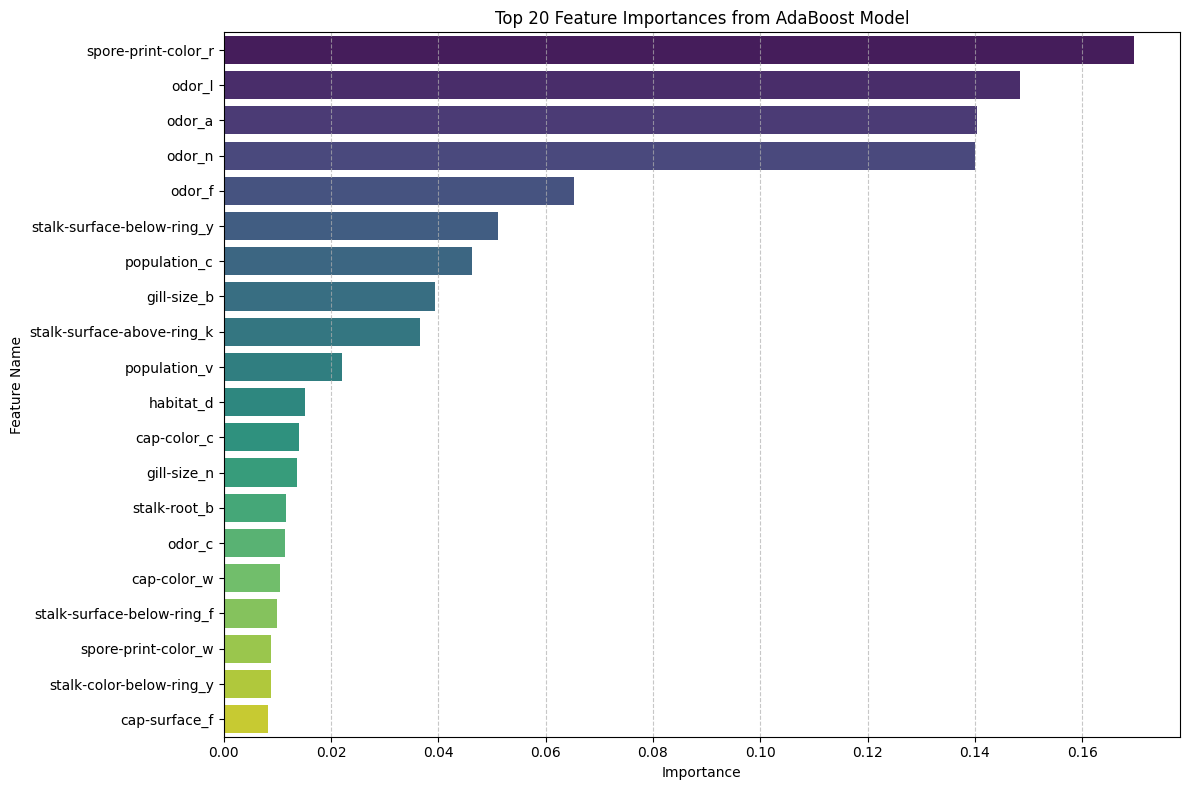

In [8]:
# Visualize the top 20 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances from AdaBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define the base estimator (Decision Stump)
base_estimator_tuned = DecisionTreeClassifier(max_depth=1, random_state=42)

# Define the parameter grid for AdaBoostClassifier
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

# Initialize GridSearchCV
# We use the base_estimator_tuned as the estimator for AdaBoost
# cv=5 for 5-fold cross-validation
# scoring='accuracy' as a metric
# n_jobs=-1 to use all available processors for faster computation
grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(estimator=base_estimator_tuned, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for AdaBoost...")
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

# Get the best model
best_adaboost_model = grid_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_tuned = best_adaboost_model.predict(X_test)

# Evaluate the best model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print(f"\nAdaBoost Classifier (Tuned) Accuracy: {accuracy_tuned:.4f}")
print("\nClassification Report (Tuned Model):\n", report_tuned)


Starting GridSearchCV for AdaBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters found:  {'learning_rate': 1.0, 'n_estimators': 100}
Best cross-validation accuracy:  1.0

AdaBoost Classifier (Tuned) Accuracy: 1.0000

Classification Report (Tuned Model):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

